<a href="https://colab.research.google.com/github/Harrison1502/Bank_Churn_Project/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/Harrison_Project/Bank_Customer_Churn_Prediction.csv'
df = pd.read_csv(file_path)
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
# Đếm số lượng giá trị bị trống ở mỗi cột
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [ ]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# Xóa cột customer_id vì nó không có giá trị phân tích dự đoán
df = df.drop(['customer_id'], axis=1)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Biến đổi các cột chữ 'country' và 'gender' thành các cột số 0 và 1
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)
df.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Tách X (Features) và y (Target)
# Drop cột churn ra khỏi X
X = df.drop('churn', axis=1)
# y chỉ lấy duy nhất cột churn
y = df['churn']

# 2. Chia thành tập Train (80%) và tập Test (20%)
# random_state=42 giống như một cái "mỏ neo" để mỗi lần chạy lại code, dữ liệu vẫn chia giống hệt nhau
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Số dòng của tập Train (X_train):", X_train.shape[0])
print("Số dòng của tập Test (X_test):", X_test.shape[0])

Số dòng của tập Train (X_train): 8000
Số dòng của tập Test (X_test): 2000


In [ ]:
# --- PHẦN 1: CHUẨN HÓA DỮ LIỆU ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Máy sẽ học các thông số từ tập Train và tự động chuẩn hóa
X_train_scaled = scaler.fit_transform(X_train)
# Sau đó áp dụng y chang công thức đó cho tập Test (không cho nó học lén tập Test)
X_test_scaled = scaler.transform(X_test)

# --- PHẦN 2: HUẤN LUYỆN MÔ HÌNH ---
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo mô hình Random Forest với 100 cây quyết định (n_estimators=100)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Cho mô hình bắt đầu "học" từ dữ liệu Train
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Bắt mô hình dự đoán trên tập Test
y_pred = model.predict(X_test_scaled)

# 2. Chấm điểm độ chính xác tổng thể (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác (Accuracy): {accuracy * 100:.2f}%\n")

# 3. Báo cáo phân loại chi tiết
print("--- BÁO CÁO PHÂN LOẠI (Classification Report) ---")
print(classification_report(y_test, y_pred))

# 4. Ma trận nhầm lẫn
print("\n--- MA TRẬN NHẦM LẪN (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred))

Độ chính xác (Accuracy): 86.65%

--- BÁO CÁO PHÂN LOẠI (Classification Report) ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000


--- MA TRẬN NHẦM LẪN (Confusion Matrix) ---
[[1550   57]
 [ 210  183]]


/tmp/ipykernel_5596/1685749999.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


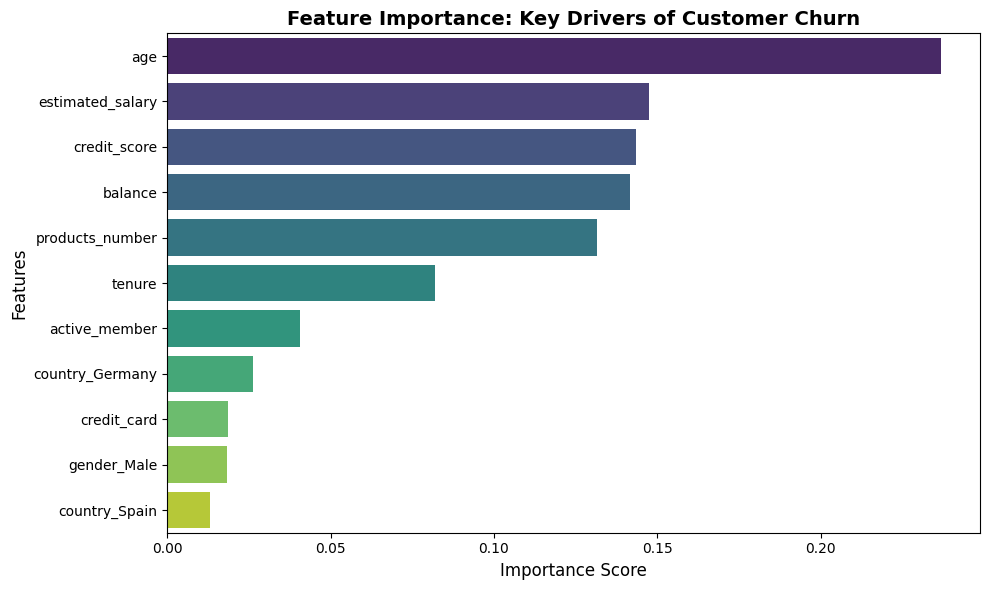

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Lấy điểm số "độ quan trọng" từ mô hình Random Forest
importances = model.feature_importances_

# 2. Lấy tên các biến (Features) từ tập dữ liệu X ban đầu
feature_names = X.columns

# 3. Gom lại thành một bảng DataFrame và sắp xếp từ cao xuống thấp
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Vẽ biểu đồ thanh ngang (Bar chart)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Feature Importance: Key Drivers of Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5596/248629135.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Inactive (0)', 'Active (1)'])
/tmp/ipykernel_5596/248629135.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='balance', data=df_viz, ax=axes[1, 2], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_5596/248629135.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 2].set_xticklabels(['Retained (0)', 'Churned (1)'])


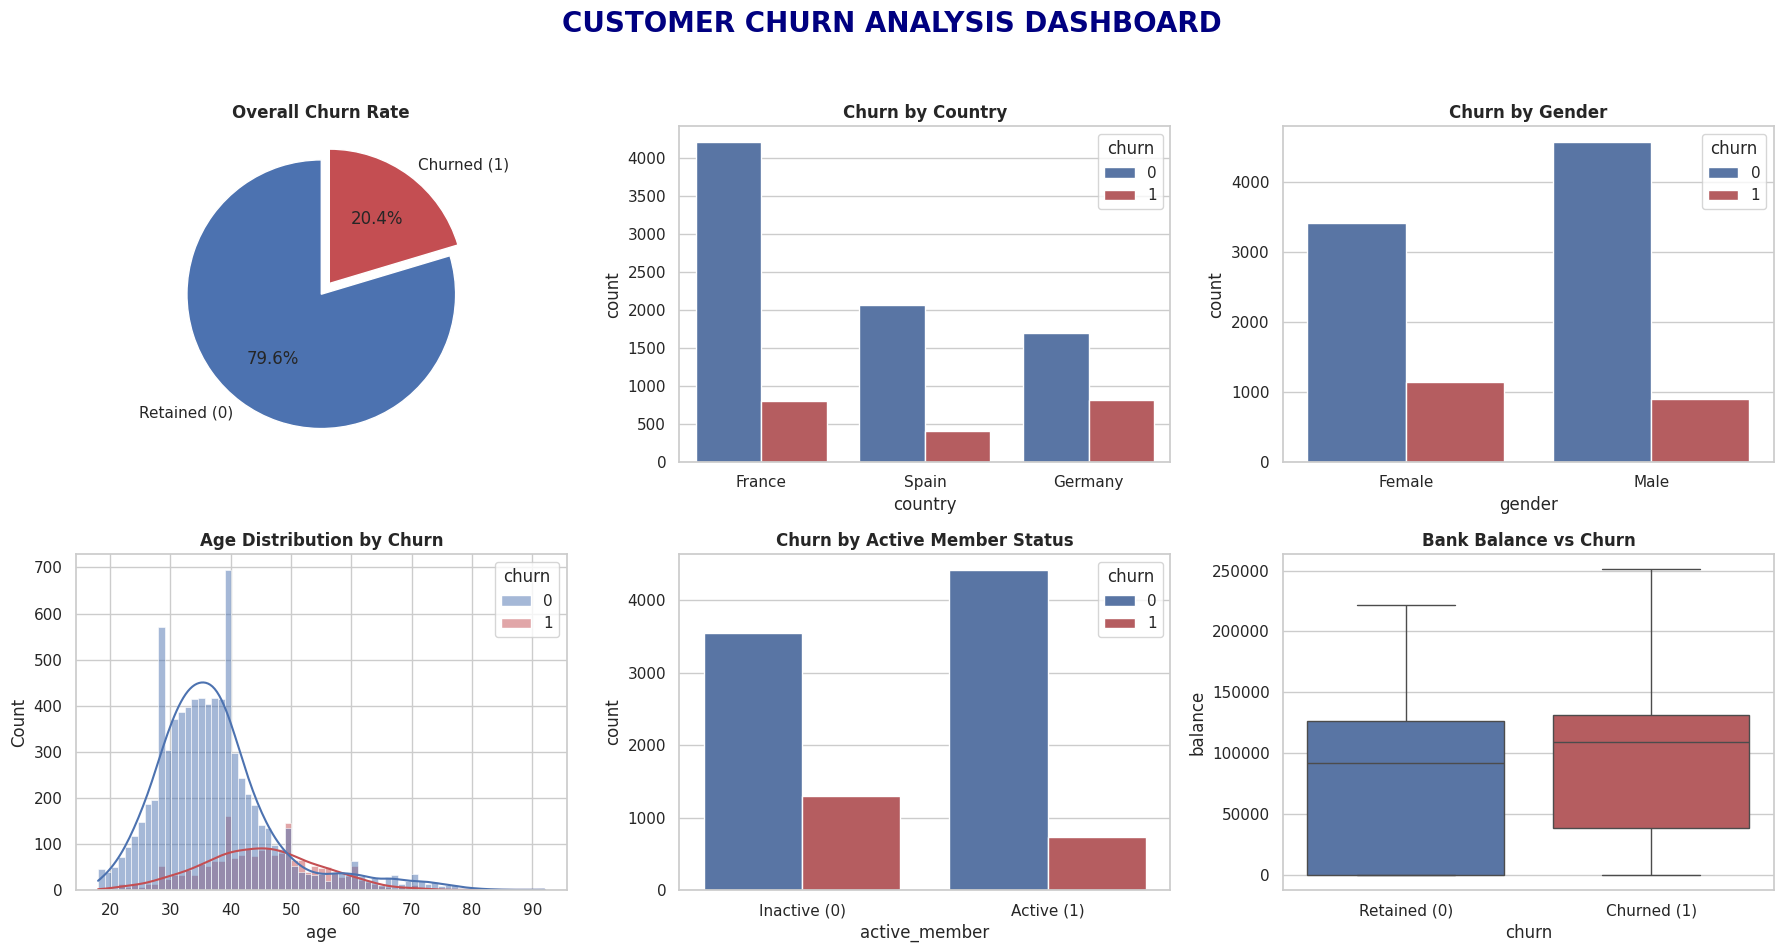

In [ ]:
df_viz = pd.read_csv(file_path)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CUSTOMER CHURN ANALYSIS DASHBOARD', fontsize=20, fontweight='bold', color='navy')

# Biểu đồ 1: Tỷ lệ Churn tổng thể
churn_counts = df_viz['churn'].value_counts()
axes[0, 0].pie(churn_counts, labels=['Retained (0)', 'Churned (1)'], autopct='%1.1f%%',
               colors=['#4C72B0', '#C44E52'], startangle=90, explode=(0, 0.1))
axes[0, 0].set_title('Overall Churn Rate', fontweight='bold')

# Biểu đồ 2: Churn theo Quốc gia
sns.countplot(x='country', hue='churn', data=df_viz, ax=axes[0, 1], palette=['#4C72B0', '#C44E52'])
axes[0, 1].set_title('Churn by Country', fontweight='bold')

# Biểu đồ 3: Churn theo Giới tính
sns.countplot(x='gender', hue='churn', data=df_viz, ax=axes[0, 2], palette=['#4C72B0', '#C44E52'])
axes[0, 2].set_title('Churn by Gender', fontweight='bold')

# Biểu đồ 4: Phân phối Tuổi tác
sns.histplot(data=df_viz, x='age', hue='churn', kde=True, ax=axes[1, 0], palette=['#4C72B0', '#C44E52'])
axes[1, 0].set_title('Age Distribution by Churn', fontweight='bold')

# Biểu đồ 5: Churn theo Active Member
sns.countplot(x='active_member', hue='churn', data=df_viz, ax=axes[1, 1], palette=['#4C72B0', '#C44E52'])
axes[1, 1].set_title('Churn by Active Member Status', fontweight='bold')
axes[1, 1].set_xticklabels(['Inactive (0)', 'Active (1)'])

# Biểu đồ 6: Boxplot Số dư tài khoản
sns.boxplot(x='churn', y='balance', data=df_viz, ax=axes[1, 2], palette=['#4C72B0', '#C44E52'])
axes[1, 2].set_title('Bank Balance vs Churn', fontweight='bold')
axes[1, 2].set_xticklabels(['Retained (0)', 'Churned (1)'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()